In [1]:
from sklearn.datasets import load_iris, make_circles, make_checkerboard
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import numpy as np

In [2]:
# Function by Jake VanderPlas
def plot_svc_decision(model, ax=None, plot_support=True):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=200, linewidth=1, facecolors='none', edgecolors="k")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

## Linear Boundaries

In [3]:
data, labels = load_iris(return_X_y=True, as_frame=True)

# We only want to classes for this example, so the steps below
# are for removing them from both X and the labels
data["label"] = labels
data = data[data["label"] != 2]

# Now do a quick PCA to make the data 2d and load the labels into
# a numpy array
X = PCA(n_components=2).fit_transform(data.drop("label", axis=1))
y = data["label"].to_numpy()

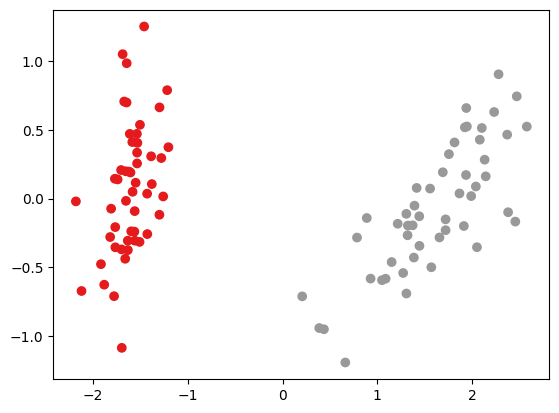

In [4]:
# Now let's plot the data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Set1")

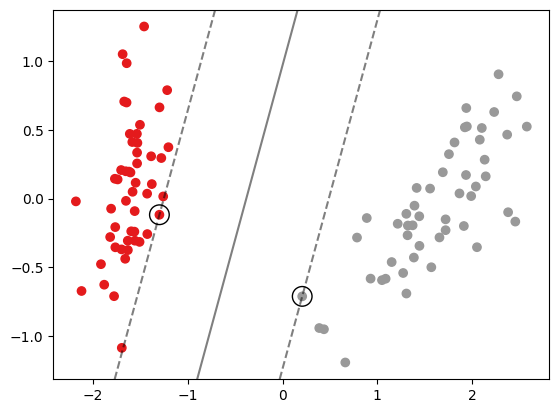

In [5]:
# Now we fit a support vector classifier
model = SVC(kernel='linear')
model.fit(X, y)

# Now lets plot it. plt.gca() gets the current axis (our scatter plot).
# The function plot_svc_decision draws the decision boundary and the support
# vectors (circled data points)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Set1")
plot_svc_decision(model, plt.gca())

In [6]:
# We can also have a look at the values of the support vectors.
model.support_vectors_

array([[-1.29873721, -0.11768298],
       [ 0.20794554, -0.71169415]])

## Non-Linear Boundaries

In [14]:
# Here, we generate some circles data
X, y = make_circles(random_state=42, factor=0.3, noise=0.05)

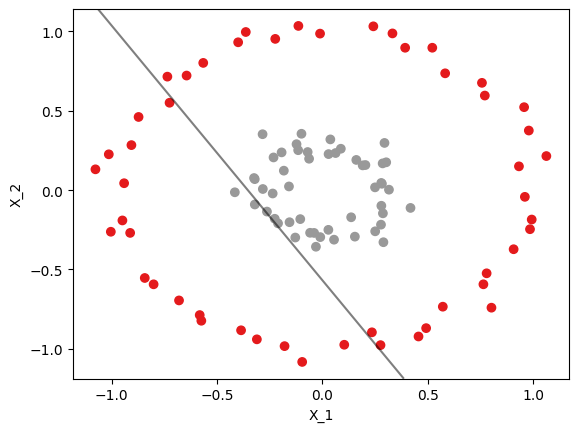

In [15]:
# ... and let's have a look at how SVC performs here.
# (Spoiler: very badly)
model = SVC(kernel='linear')
model.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Set1")
plt.xlabel("X_1")
plt.ylabel("X_2")
plot_svc_decision(model, plt.gca(), plot_support=False);

Text(0, 0.5, 'X_2')

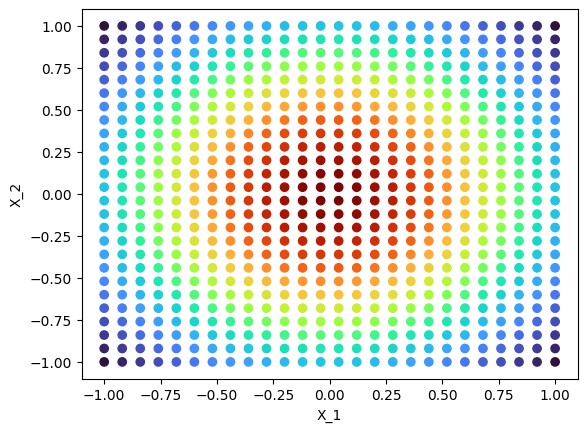

In [16]:
# What we can do now is project the data into a higher dimension.
# We do this using a so-called radial basis function (think a 2d gaussian,
# centered in the middle of our data points). Let's look at an example of 
# a grid of equally spaced points
grid = np.meshgrid(
    np.linspace(-1, 1, 26),
    np.linspace(-1, 1, 26),
    sparse=False)

X_grid = np.array(grid).T.reshape(-1,2)
rbf = np.exp(-(X_grid**2).sum(1))
plt.scatter(X_grid[:, 0], X_grid[:, 1], c=rbf, cmap="turbo")
plt.xlabel("X_1")
plt.ylabel("X_2")


Text(0, 0.5, 'X_2')

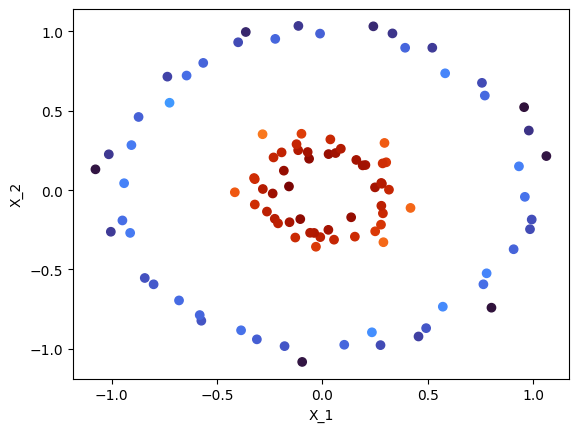

In [17]:
# Now we colour the points of the circles using this radial basis function:
rbf = np.exp(-(X**2).sum(1))
plt.scatter(X[:, 0], X[:, 1], c=rbf, cmap="turbo")
plt.xlabel("X_1")
plt.ylabel("X_2")

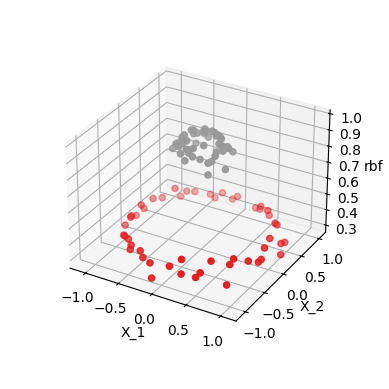

In [24]:
# Let's visualise this a bit differently...
ax = plt.subplot(projection="3d")
ax.scatter3D(X[:, 0], X[:, 1], rbf, c=y, cmap="Set1")
ax.set_xlabel("X_1")
ax.set_ylabel("X_2")
ax.set_zlabel("rbf")
ax.set_box_aspect(aspect=None, zoom=0.8)

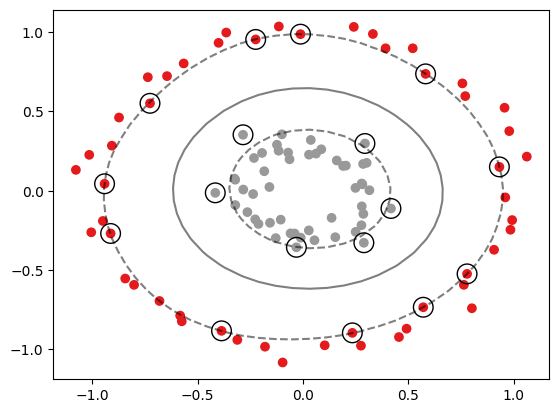

In [145]:
# The classes now separate nicely!
# Luckily, we can just tell the SVC class to use a radial basis function
# and don't have to do this ourselves all the time
model = SVC(kernel="rbf")
model.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Set1")
plot_svc_decision(model, plt.gca())


